Nodes: 35, meta-edges: 308
Narratives present: ['Politik & Tuntutan', 'Kekerasan Aparat', 'Gerakan/Hashtag', 'Demo & DPR', 'Ekonomi Rakyat']


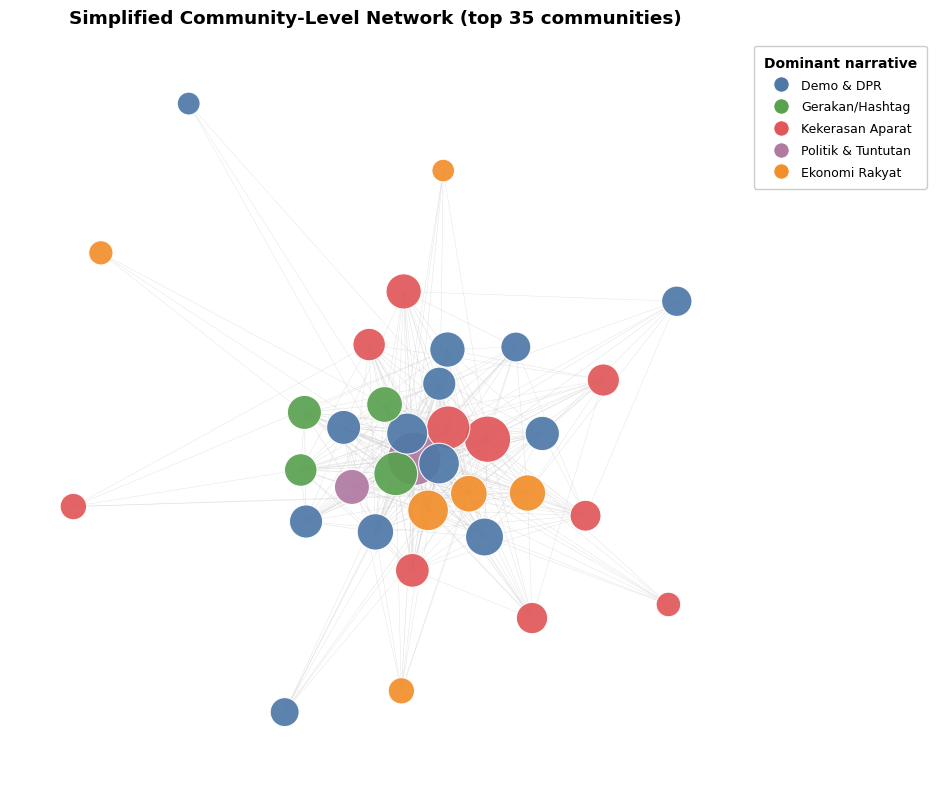

In [7]:
# =============================================================
# Figure S3 — Simplified Community-Level (Meta-)Network
# Nodes = Louvain communities (colored by dominant narrative)
# Edges = cross-community interaction volume
# Answers Reviewer 1, 4.1: demonstrate cross-community diffusion + simplified network
# =============================================================
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ---- EDIT PATHS IF NEEDED ----
PATH_NODES = 'network_nodes_with_community3.csv'   # sep=';'
PATH_EDGES = 'network_edges.csv'                   # sep=','
PATH_NARR  = 'Data_with_community3.csv'            # sep=';'  (has 'narrative')
TOP_N = 40
SEED  = 42

# ---- Load ----
nodes = pd.read_csv(PATH_NODES, sep=';', encoding='utf-8-sig')
edges = pd.read_csv(PATH_EDGES)
narr  = pd.read_csv(PATH_NARR, sep=';', encoding='utf-8-sig')

# ---- Normalise usernames identically everywhere ----
def norm(s):
    return s.astype(str).str.strip().str.lstrip('@').str.lower()

nodes['username'] = norm(nodes['username'])
edges['source']   = norm(edges['source'])
edges['target']   = norm(edges['target'])

# username column in narrative file: prefer username_clean, else username
u_narr = 'username_clean' if 'username_clean' in narr.columns else 'username'
narr[u_narr] = norm(narr[u_narr])

# ---- Map account -> community ----
comm_map = dict(zip(nodes['username'], nodes['community']))
comm_size = nodes.groupby('community').size()

# ---- Dominant narrative per community ----
# Each account's dominant narrative = its most frequent narrative in the tweet data
acct_narr = (narr.dropna(subset=['narrative'])
                 .groupby(u_narr)['narrative']
                 .agg(lambda g: g.value_counts().idxmax()))
narr_df = pd.DataFrame({'username': acct_narr.index, 'narrative': acct_narr.values})
narr_df['community'] = narr_df['username'].map(comm_map)
narr_df = narr_df.dropna(subset=['community'])
narr_df['community'] = narr_df['community'].astype(int)

# community -> dominant narrative (mode across its member accounts)
comm_narr = (narr_df.groupby('community')['narrative']
                    .agg(lambda g: g.value_counts().idxmax()))

# ---- Build cross-community meta-edges ----
edges['src_comm'] = edges['source'].map(comm_map)
edges['tgt_comm'] = edges['target'].map(comm_map)
edges = edges.dropna(subset=['src_comm', 'tgt_comm']).copy()
edges['src_comm'] = edges['src_comm'].astype(int)
edges['tgt_comm'] = edges['tgt_comm'].astype(int)
cross = edges[edges['src_comm'] != edges['tgt_comm']].copy()

top_comms = comm_size.sort_values(ascending=False).head(TOP_N).index.tolist()
cross_top = cross[cross['src_comm'].isin(top_comms) & cross['tgt_comm'].isin(top_comms)].copy()
cross_top['pair'] = cross_top.apply(lambda r: tuple(sorted((r['src_comm'], r['tgt_comm']))), axis=1)
w_col = 'weight' if 'weight' in cross_top.columns else None
meta_w = (cross_top.groupby('pair')[w_col].sum() if w_col
          else cross_top.groupby('pair').size())

# ---- Assemble graph ----
G = nx.Graph()
for c in top_comms:
    G.add_node(c, size=int(comm_size[c]),
               narr=str(comm_narr.get(c, 'Unassigned')))
for (a, b), w in meta_w.items():
    G.add_edge(a, b, weight=float(w))
G.remove_nodes_from([n for n in list(G.nodes) if G.degree(n) == 0])

# ---- Color palette per narrative (7 categories + fallback) ----
NARR_COLORS = {
    'Demo & DPR':               '#4E79A7',  # Parliament & Protest
    'Gerakan/Hashtag':          '#59A14F',  # Movement Coordination
    'Kekerasan Aparat':         '#E15759',  # State Apparatus Violence
    'Politik & Tuntutan':       '#B07AA1',  # Politics & Demands
    'Ekonomi Rakyat':           '#F28E2B',  # Economic Grievance
    'Affan Kurniawan':          '#EDC948',  # Affan Kurniawan
    'Keamanan & Respons':       '#76B7B2',  # Security & Response
}
FALLBACK = '#BAB0AC'

present = []
for n in G.nodes:
    lab = G.nodes[n]['narr']
    if lab in NARR_COLORS and lab not in present:
        present.append(lab)
node_colors = [NARR_COLORS.get(G.nodes[n]['narr'], FALLBACK) for n in G.nodes]

sizes = np.array([G.nodes[n]['size'] for n in G.nodes], dtype=float)
node_sizes = 80 + 1400 * (np.sqrt(sizes) / np.sqrt(sizes.max()))
ews = np.array([G[u][v]['weight'] for u, v in G.edges], dtype=float)
edge_widths = 0.3 + 4.0 * (ews / ews.max())

# ---- Draw ----
plt.rcParams.update({'font.family': 'sans-serif', 'font.size': 11,
                     'savefig.dpi': 300, 'savefig.bbox': 'tight'})
fig, ax = plt.subplots(figsize=(9.5, 8))
pos = nx.spring_layout(G, k=1.6, seed=SEED, weight='weight')  # k higher = less clumping

nx.draw_networkx_edges(G, pos, ax=ax, width=edge_widths, edge_color='#CCCCCC', alpha=0.55)
nx.draw_networkx_nodes(G, pos, ax=ax, node_size=node_sizes, node_color=node_colors,
                       alpha=0.92, edgecolors='white', linewidths=0.8)
ax.set_axis_off()
ax.set_title(f'Simplified Community-Level Network (top {G.number_of_nodes()} communities)',
             fontweight='bold', pad=12)

# ---- Legend: clean, ordered, only narratives present ----
order = ['Demo & DPR', 'Gerakan/Hashtag', 'Kekerasan Aparat', 'Politik & Tuntutan',
         'Ekonomi Rakyat', 'Affan Kurniawan', 'Keamanan & Respons']

handles = [
    plt.Line2D([0], [0], marker='o', linestyle='none',
               markerfacecolor=NARR_COLORS[k], markeredgecolor='white',
               markeredgewidth=0.6, markersize=11, label=k)
    for k in order if k in present
]
if any(G.nodes[n]['narr'] not in NARR_COLORS for n in G.nodes):
    handles.append(
        plt.Line2D([0], [0], marker='o', linestyle='none',
                   markerfacecolor=FALLBACK, markeredgecolor='white',
                   markeredgewidth=0.6, markersize=11, label='Unassigned')
    )

legend = ax.legend(
    handles=handles,
    title='Dominant narrative',
    loc='upper left',
    bbox_to_anchor=(1.01, 1.0),   # push legend just outside the plot area
    frameon=True,
    edgecolor='#cccccc',
    framealpha=1.0,
    fontsize=9,
    title_fontsize=10,
    labelspacing=0.7,             # vertical gap between entries
    handletextpad=0.6,            # gap between marker and text
    borderpad=0.8,                # padding inside the frame
)
legend.get_title().set_fontweight('bold')

plt.tight_layout()
fig.savefig('FigureS3_community_network.png', dpi=300, bbox_inches='tight')
fig.savefig('FigureS3_community_network.pdf', bbox_inches='tight')
print(f'Nodes: {G.number_of_nodes()}, meta-edges: {G.number_of_edges()}')
print('Narratives present:', present)
plt.show()